In [5]:
import torch
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from urbansound.urbansounddataset import UrbanSoundDataset, ANNOTATIONS_FILE, AUDIO_DIR, SAMPLE_RATE, NUM_SAMPLES
from urbansound.multi_branch_lightning import LitMultiBranchFusion

# Class names mapping roughly for UrbanSound8K
class_names = {
    0: 'air_conditioner', 1: 'car_horn', 2: 'children_playing', 3: 'dog_bark',
    4: 'drilling', 5: 'engine_idling', 6: 'gun_shot', 7: 'jackhammer',
    8: 'siren', 9: 'street_music'
}

# 1. Setup Data Loading
device = "cuda" if torch.cuda.is_available() else "cpu"
dataset = UrbanSoundDataset(
    ANNOTATIONS_FILE,
    AUDIO_DIR,
    lambda x: x, # Dummy transform since LitMultiBranchFusion does the transforms
    SAMPLE_RATE,
    NUM_SAMPLES,
    device
)

# Pick a sample
sample_index = 783
waveform, label = dataset[sample_index]
class_name = class_names.get(label, "Unknown")
print(f"Sample {sample_index}: Class {label} ({class_name}), Waveform shape: {waveform.shape}")

# 2. Extract Features using the model's exact method
# We need to unsqueeze to add batch dimension (Batch, Time)
waveform_batch = waveform.unsqueeze(0)

Sample 783: Class 9 (street_music), Waveform shape: torch.Size([1, 88200])


In [6]:
model = LitMultiBranchFusion(num_classes=10)
model.eval()

with torch.no_grad():
    mel_spec, mfcc, global_stats = model.extract_features(waveform_batch)

# Remove batch dimension for visualization
mel_spec_vis = mel_spec.squeeze(0).cpu().numpy()
mfcc_vis = mfcc.squeeze(0).cpu().numpy() # [time, mfcc]
global_stats_vis = global_stats.squeeze(0).cpu().numpy() # [4]

print(f"CNN Input (Mel Spec) shape: {mel_spec_vis.shape}")
print(f"GRU Input (MFCC) shape: {mfcc_vis.shape}")
print(f"Engineered Input shape: {global_stats_vis.shape}")

CNN Input (Mel Spec) shape: (1, 128, 173)
GRU Input (MFCC) shape: (173, 40)
Engineered Input shape: (4,)


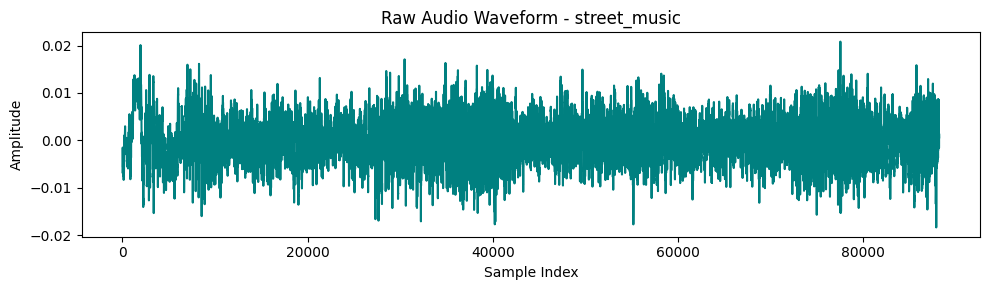

In [7]:
# 3. Visualization

# First, display the waveform
plt.figure(figsize=(10, 3))
plt.plot(waveform.squeeze().numpy(), color='teal')
plt.title(f"Raw Audio Waveform - {class_name}")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Display the playable audio widget
display(Audio(waveform.squeeze().numpy(), rate=SAMPLE_RATE))


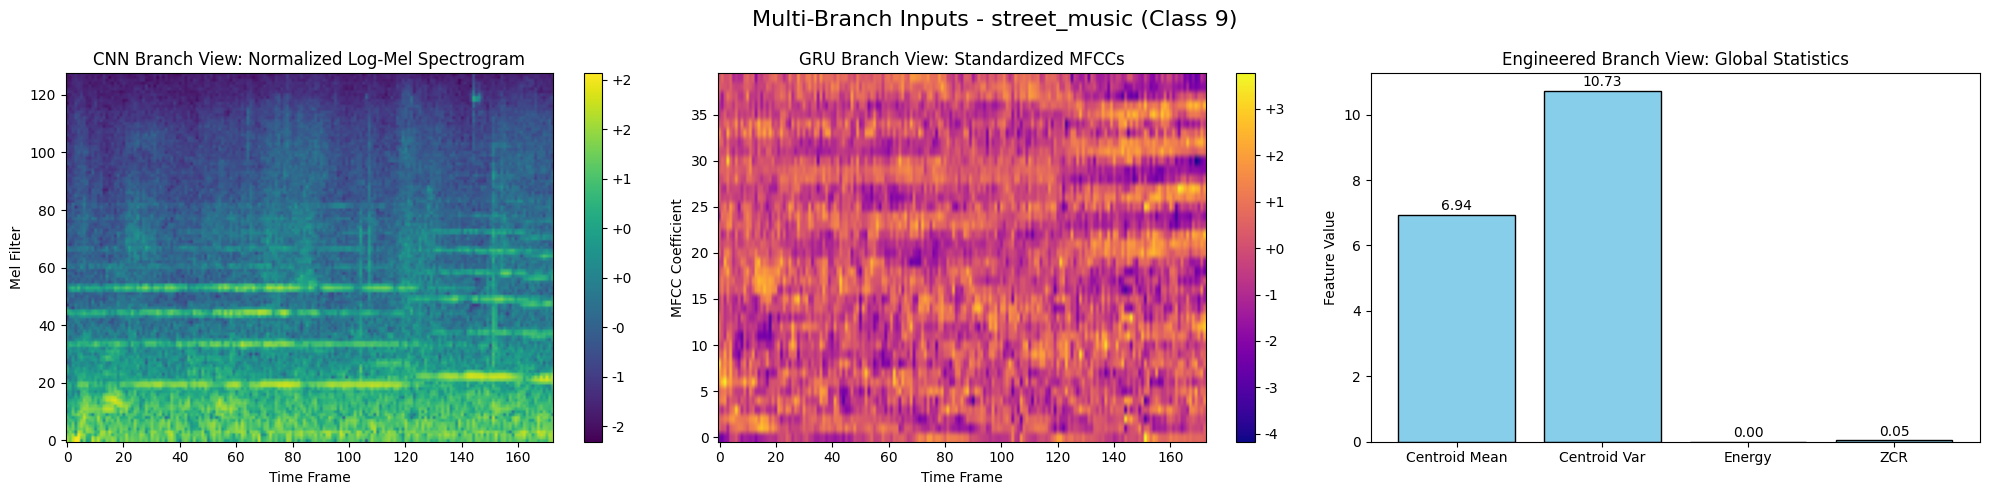

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(f'Multi-Branch Inputs - {class_name} (Class {label})', fontsize=16)

# Plot CNN Input (Mel Spectrogram)
# mel_spec_vis shape should be (1, n_mels, time) or (n_mels, time) depending on the shape returned.
# In LitMultiBranchFusion, it's (Batch, n_mels, time) initially, then normalized.
# The code doesn't unsqueeze(1) explicitly in the current multi_branch_lightning.py,
# wait, looking at the code, it uses (Batch, n_mels, time). Wait, we should squeeze 0 for batch.
if len(mel_spec_vis.shape) == 3:
    mel_spec_vis = mel_spec_vis[0] # remove channel if it's there
elif len(mel_spec_vis.shape) == 2:
    pass

ax = axes[0]
img = ax.imshow(mel_spec_vis, aspect='auto', origin='lower', cmap='viridis')
ax.set_title("CNN Branch View: Normalized Log-Mel Spectrogram")
ax.set_ylabel("Mel Filter")
ax.set_xlabel("Time Frame")
fig.colorbar(img, ax=ax, format="%+2.f")

# Plot GRU Input (MFCCs)
# mfcc_vis is [time, n_mfcc]
ax = axes[1]
# We transpose to [n_mfcc, time] for plotting convention
img = ax.imshow(mfcc_vis.T, aspect='auto', origin='lower', cmap='plasma')
ax.set_title("GRU Branch View: Standardized MFCCs")
ax.set_ylabel("MFCC Coefficient")
ax.set_xlabel("Time Frame")
fig.colorbar(img, ax=ax, format="%+2.f")

# Plot Engineered Input (Global Stats)
ax = axes[2]
eng_features = ['Centroid Mean', 'Centroid Var', 'Energy', 'ZCR']
ax.bar(eng_features, global_stats_vis, color='skyblue', edgecolor='black')
ax.set_title("Engineered Branch View: Global Statistics")
ax.set_ylabel("Feature Value")

# Add value labels on top of bars
for i, v in enumerate(global_stats_vis):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Last recorded alpha value in the first iteration of 10-fold cross-validation (fold 1 as validation) was:

`0.9676064848899841,0.03227549046278,0.00011811201693490148`

Meaning: the CNN branch has the most attention when it comes to the final decision of the model, while the other two branches (GRU and MLP) have very little attention.